In [1]:
import pandas as pd

df = pd.read_excel(r"C:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\cleaned_data.xlsx")

In [2]:
len(df)

50000

In [3]:
df_body_title_tags = df[["cleaned_Body", "cleaned_Title", "Tags"]]

In [4]:
df_body_title_tags

,cleaned_Body,cleaned_Title,Tags
0,page collection linq give startindex count,page collection linq,<linq><.net-3.5>
1,want format exist comment rdoc comment view ri...,add exist comment rdoc ruby,<ruby><rdoc>
2,version subclipse currently available aptana a...,get subclipse aptana work new release subversion,<eclipse><svn><aptana><subclipse>
3,write database generation script sql want exec...,multiple query statement,<apache-flex><actionscript-3><air>
4,good practice create flat file database struct...,flat file database,<php><sql><database><flat-file>
...,...,...,...
49995,try determine way visual basic 2008 express ed...,collection initialization syntax visual basic ...,<vb.net><visual-studio-2008><collections><init...
49996,look ruby equivalent code like pythonista idio...,tutorial teach common ruby programming idiom e...,<ruby><idioms>
49997,try scour web help issue generic word find rel...,xml notepad 2007 break ms access 2007 help,<xml><ms-office>
49998,read flickr api documentation keep state requi...,need flickr api key,<flickr>


In [5]:
from sklearn.feature_extraction.text import CountVectorizer

In [6]:
def remove_html_tags(text):
    """Remove HTML tags from a string."""
    text = text.str.replace(r"><", ",", regex=True)
    text = text.str.replace(r">|<", "", regex=True)
    return (text)

df_body_title_tags["Tags"] = remove_html_tags(df_body_title_tags["Tags"])

C:\Users\solay\AppData\Local\Temp\ipykernel_3044\188697831.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_body_title_tags["Tags"] = remove_html_tags(df_body_title_tags["Tags"])


In [7]:
df_body_title_tags

,cleaned_Body,cleaned_Title,Tags
0,page collection linq give startindex count,page collection linq,"linq,.net-3.5"
1,want format exist comment rdoc comment view ri...,add exist comment rdoc ruby,"ruby,rdoc"
2,version subclipse currently available aptana a...,get subclipse aptana work new release subversion,"eclipse,svn,aptana,subclipse"
3,write database generation script sql want exec...,multiple query statement,"apache-flex,actionscript-3,air"
4,good practice create flat file database struct...,flat file database,"php,sql,database,flat-file"
...,...,...,...
49995,try determine way visual basic 2008 express ed...,collection initialization syntax visual basic ...,"vb.net,visual-studio-2008,collections,initiali..."
49996,look ruby equivalent code like pythonista idio...,tutorial teach common ruby programming idiom e...,"ruby,idioms"
49997,try scour web help issue generic word find rel...,xml notepad 2007 break ms access 2007 help,"xml,ms-office"
49998,read flickr api documentation keep state requi...,need flickr api key,flickr


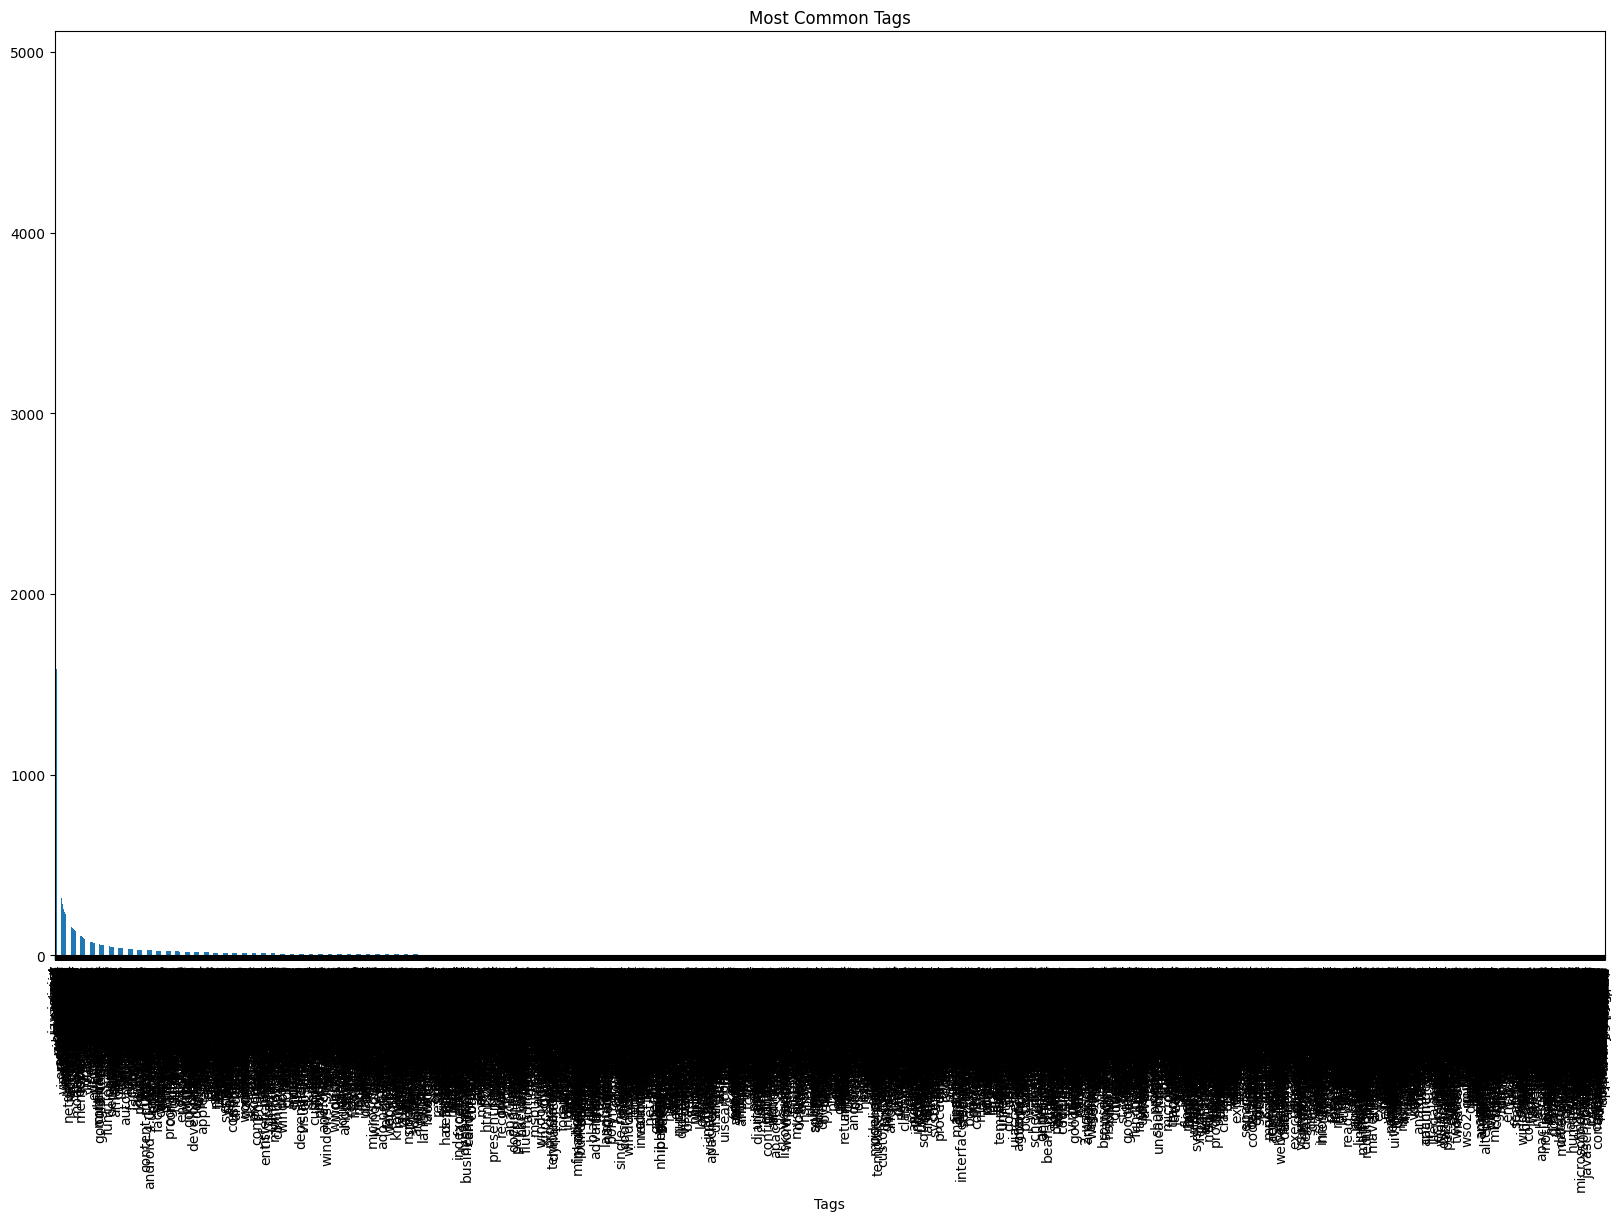

In [8]:
import matplotlib.pyplot as plt
all_tags = df_body_title_tags["Tags"].str.split(",").explode().value_counts()
all_tags.sort_values(ascending=False).plot(kind='bar', figsize=(20, 12), title="Most Common Tags")
plt.show()

In [9]:
all_tags = all_tags[all_tags >= 2]

In [10]:
all_tags_bis = all_tags[:50]

In [11]:
tag_to_keep = all_tags_bis.index.to_list()

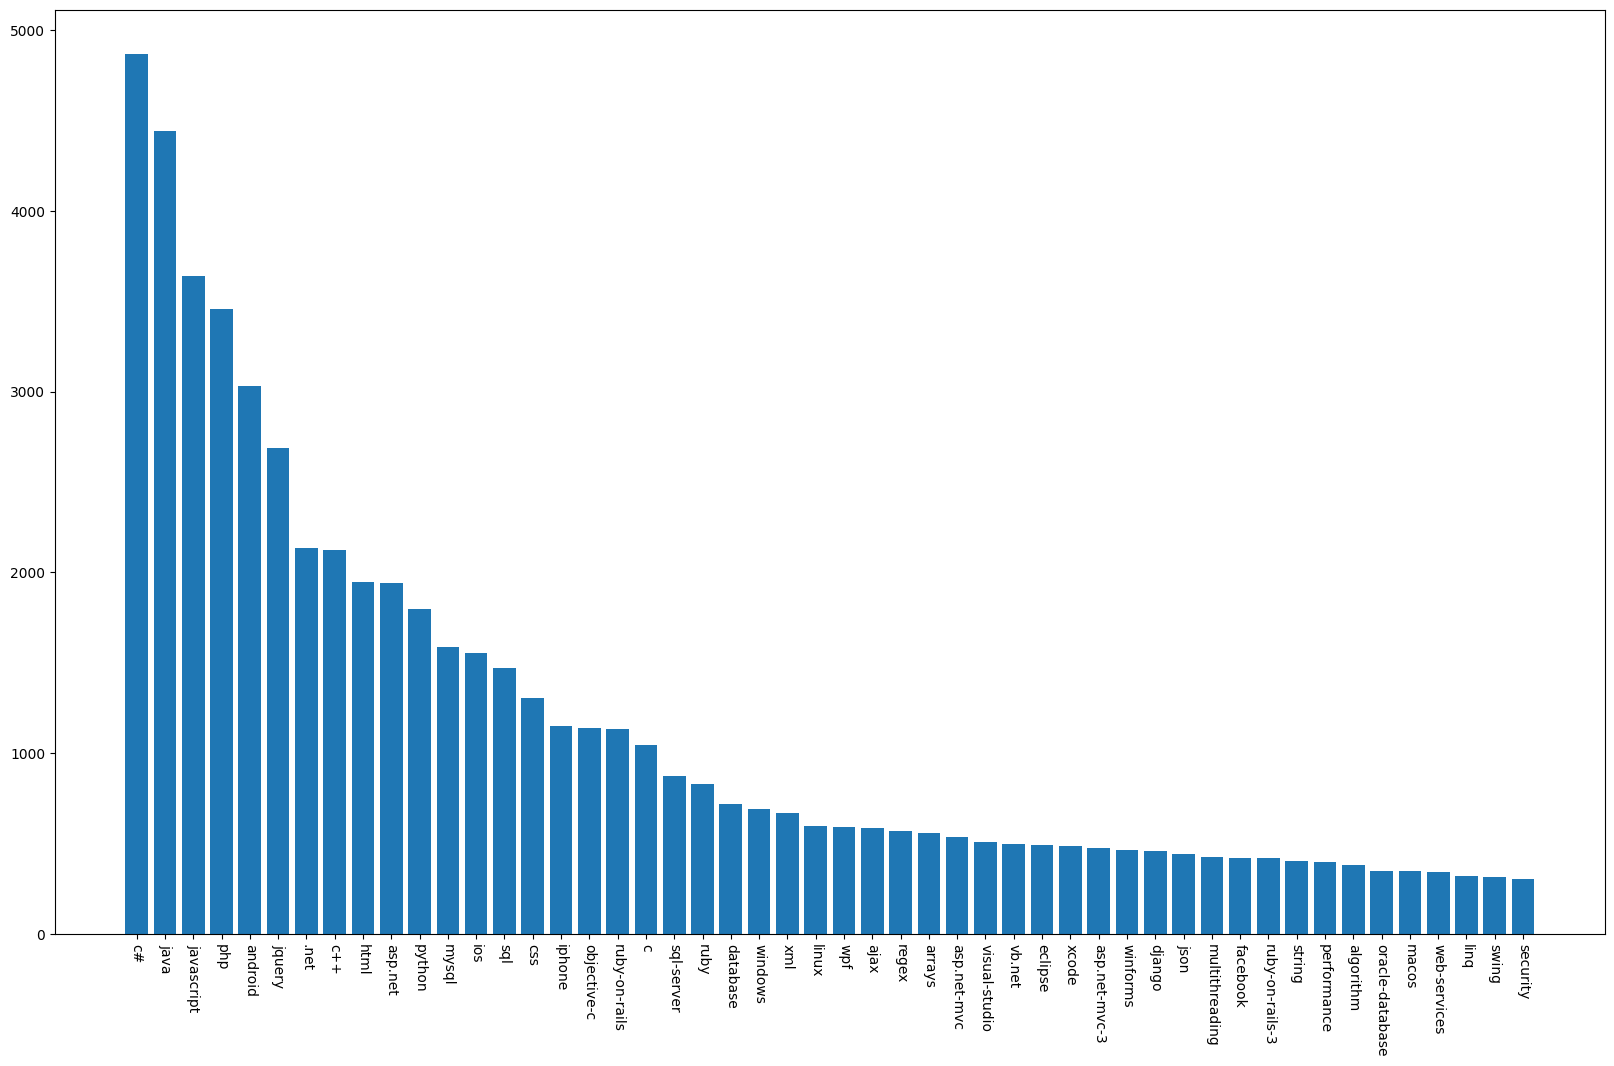

In [12]:
plt.figure(figsize=(20, 12))
plt.bar(all_tags_bis.index, all_tags_bis.values)
plt.xticks(rotation=-90)
plt.show()

In [13]:
Y = df_body_title_tags["Tags"].str.get_dummies(sep=",")

In [21]:
Y = Y[all_tags_bis.index]

In [15]:
df_final = pd.concat([df_body_title_tags["cleaned_Body"], Y], axis=1)

In [16]:
df_sample = df_final.sample(frac=0.1, random_state=42)
cols_to_drop = [col for col in df_sample.columns if df_sample[col].nunique == 1]
df_sample_final = df_sample.drop(columns=cols_to_drop)

In [17]:
df_sample_final.shape

(5000, 51)

In [18]:
from sklearn.model_selection import train_test_split

# Séparation en train/test (80% train, 20% test)
body_train, body_test, Y_train, Y_test = train_test_split(df_sample_final["cleaned_Body"], df_sample_final.drop("cleaned_Body", axis=1), test_size=0.2, random_state=42)

In [19]:
#CountVectorizer fit transform sur body train et transform sur body Y_test

#entrainer un model de regression logistique en utilisant la fonction multioutputclassifier de sklearn
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(body_train.fillna(""))
X_test = vectorizer.transform(body_test.fillna(""))
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression

# Remove columns with only one class in Y_train
valid_cols = [col for col in Y_train.columns if len(Y_train[col].unique()) > 1]
Y_train_valid = Y_train[valid_cols]
Y_test_valid = Y_test[valid_cols]

classifier = MultiOutputClassifier(LogisticRegression(max_iter=1000))
classifier.fit(X_train, Y_train_valid)
# Prédiction sur le test set
Y_pred = classifier.predict(X_test)
from sklearn.metrics import accuracy_score, f1_score
# Calcul de l'accuracy et du f1 score
accuracy = accuracy_score(Y_test_valid, Y_pred)
f1 = f1_score(Y_test_valid, Y_pred, average='weighted')
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
# Sauvegarde du modèle et du vectorizer

Accuracy: 0.2940
F1 Score: 0.3439


In [20]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import KFold
def evaluate_onevsrest_with_estimators(body_train, body_test, Y_train, Y_test, estimators=None, cv=5, random_state=42):
    if estimators is None:
        estimators = {
            'LogisticRegression': LogisticRegression(max_iter=1000, random_state=random_state),
            'RandomForest': RandomForestClassifier(n_estimators=100, random_state=random_state),
            'LinearSVC': LinearSVC(max_iter=2000, random_state=random_state)
        }
    vectorizer = CountVectorizer()
    # Ensure we don't pass NaN to CountVectorizer (it expects strings)
    X_train = vectorizer.fit_transform(body_train.fillna("").astype(str))
    X_test = vectorizer.transform(body_test.fillna("").astype(str))
    results = []
    kf = KFold(n_splits=cv, shuffle=True, random_state=random_state)
    for est_name, base_estimator in estimators.items():
        model = OneVsRestClassifier(base_estimator)
        f1_scores = []
        acc_scores = []
        for train_idx, val_idx in kf.split(X_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            Y_tr, Y_val = Y_train.iloc[train_idx], Y_train.iloc[val_idx]
            # Remove columns with only one unique value in this fold's training set
            valid_cols = [col for col in Y_tr.columns if len(Y_tr[col].unique()) > 1]
            if len(valid_cols) == 0:
                continue
            Y_tr_valid = Y_tr[valid_cols]
            Y_val_valid = Y_val[valid_cols]
            try:
                model.fit(X_tr, Y_tr_valid)
                Y_pred = model.predict(X_val)
                f1 = f1_score(Y_val_valid, Y_pred, average='weighted', zero_division=0)
                acc = accuracy_score(Y_val_valid, Y_pred)
                f1_scores.append(f1)
                acc_scores.append(acc)
            except Exception as e:
                continue
        # CV mean scores:!x!s:s;q;/S.S./QSQ/S.S.Q
        f1_cv = np.mean(f1_scores) if f1_scores else np.nan
        acc_cv = np.mean(acc_scores) if acc_scores else np.nan 
        # Train on full training set (with columns that have more than one class)
        valid_cols_full = [col for col in Y_train.columns if len(Y_train[col].unique()) > 1]
        Y_train_valid = Y_train[valid_cols_full]
        Y_test_valid = Y_test[valid_cols_full]
        model.fit(X_train, Y_train_valid)
        Y_pred_test = model.predict(X_test)
        f1_test = f1_score(Y_test_valid, Y_pred_test, average='weighted', zero_division=0)
        acc_test = accuracy_score(Y_test_valid, Y_pred_test)
        results.append({
            'BaseEstimator': est_name,
            'CV Accuracy': acc_cv,
            'CV F1': f1_cv,
            'Test Accuracy': acc_test,
            'Test F1': f1_test
        })
    return pd.DataFrame(results)
# Exemple d'utilisation :
df_results = evaluate_onevsrest_with_estimators(body_train, body_test, Y_train, Y_test)
print(df_results)

        BaseEstimator  CV Accuracy     CV F1  Test Accuracy   Test F1
0  LogisticRegression      0.29200  0.331808          0.294  0.343912
1        RandomForest      0.25575  0.058472          0.257  0.066739
2           LinearSVC      0.25850  0.349291          0.260  0.361834


In [21]:
from sklearn.multioutput import ClassifierChain

cc = ClassifierChain(LogisticRegression(max_iter=1000))
cc.fit(X_train, Y_train_valid)

Y_pred_cc = cc.predict(X_test)
accuracy_cc = accuracy_score(Y_test_valid, Y_pred_cc)
f1_cc = f1_score(Y_test_valid, Y_pred_cc, average='weighted')
print(f"Classifier Chain Accuracy: {accuracy_cc:.4f}")
print(f"Classifier Chain F1 Score: {f1_cc:.4f}")

Classifier Chain Accuracy: 0.2950
Classifier Chain F1 Score: 0.3439


In [22]:
Y_train_valid

,c#,java,javascript,php,android,jquery,.net,c++,html,asp.net,...,ruby-on-rails-3,string,performance,algorithm,oracle-database,macos,web-services,linq,swing,security
21535,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
24602,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
28786,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
36535,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
23905,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12793,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9807,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
7497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6013,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [23]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
Y_train_mlb = mlb.fit_transform(Y_train_valid.values)
Y_test_mlb = mlb.transform(Y_test_valid.values)

ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000))
ovr.fit(X_train, Y_train_mlb)
Y_pred_mlb = ovr.predict(X_test)
accuracy_mlb = accuracy_score(Y_test_mlb, Y_pred_mlb)
f1_mlb = f1_score(Y_test_mlb, Y_pred_mlb, average='weighted')
print(f"MLB Accuracy: {accuracy_mlb:.4f}")
print(f"MLB F1 Score: {f1_mlb:.4f}")


c:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label 0 is present in all training examples.
  warnings.warn(


MLB Accuracy: 0.7250
MLB F1 Score: 0.9222


## Création du modèle Word2Vec

In [24]:
import gensim
from tensorflow.keras.preprocessing.text import Tokenizer

In [25]:
w2v_size=300
w2v_window=5
w2v_min_count=1
w2v_epochs=100
maxlen = 24 # adapt to length of sentences
sentences = df_final['cleaned_Body'].to_list()
sentences = [gensim.utils.simple_preprocess(text) for text in sentences]

TypeError: decoding to str: need a bytes-like object, float found

In [26]:
# Création et entraînement du modèle Word2Vec

print("Build & train Word2Vec model ...")
w2v_model = gensim.models.Word2Vec(min_count=w2v_min_count, window=w2v_window,
                                                vector_size=w2v_size,
                                                seed=42,
                                                workers=1)
#                                                workers=multiprocessing.cpu_count())
w2v_model.build_vocab(sentences)
w2v_model.train(sentences, total_examples=w2v_model.corpus_count, epochs=w2v_epochs)
model_vectors = w2v_model.wv
w2v_words = model_vectors.index_to_key
print("Vocabulary size: %i" % len(w2v_words))
print("Word2Vec trained")

Build & train Word2Vec model ...


TypeError: 'float' object is not iterable

In [27]:
# Préparation des sentences (tokenization)
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("Fit Tokenizer ...")
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)
x_sentences = pad_sequences(tokenizer.texts_to_sequences(sentences),
                                                     maxlen=maxlen,
                                                     padding='post') 
                                                   
num_words = len(tokenizer.word_index) + 1
print("Number of unique words: %i" % num_words)

Fit Tokenizer ...


AttributeError: 'float' object has no attribute 'lower'

## Création de la matrice d'embedding

In [28]:
# Création de la matrice d'embedding
import numpy as np

print("Create Embedding matrix ...")
w2v_size = 300
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1
embedding_matrix = np.zeros((vocab_size, w2v_size))
i=0
j=0
    
for word, idx in word_index.items():
    i +=1
    if word in w2v_words:
        j +=1
        embedding_vector = model_vectors[word]
        if embedding_vector is not None:
            embedding_matrix[idx] = model_vectors[word]
            
word_rate = np.round(j/i,4)
print("Word embedding rate : ", word_rate)
print("Embedding matrix: %s" % str(embedding_matrix.shape))

Create Embedding matrix ...


ZeroDivisionError: division by zero

## Création du modèle d'embedding

In [29]:
# Création du modèle
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

input=Input(shape=(len(x_sentences),maxlen),dtype='float64')
word_input=Input(shape=(maxlen,),dtype='float64')  
word_embedding=Embedding(input_dim=vocab_size,
                         output_dim=w2v_size,
                         weights = [embedding_matrix],
                         input_length=maxlen)(word_input)
word_vec=GlobalAveragePooling1D()(word_embedding)  
embed_model = Model([word_input],word_vec)

embed_model.summary()

NameError: name 'x_sentences' is not defined

## Exécution du modèle

In [30]:
embeddings = embed_model.predict(x_sentences)
embeddings.shape

NameError: name 'embed_model' is not defined

In [31]:
# Séparation en train/test (80% train, 20% test)
emb_train, emb_test, Y_train, Y_test = train_test_split(embeddings, Y, test_size=0.2, random_state=42)

NameError: name 'embeddings' is not defined

In [32]:
#CountVectorizer fit transform sur body train et transform sur body Y_test

#entrainer un model de regression logistique en utilisant la fonction multioutputclassifier de sklearn
# Remove columns with only one class in Y_train
valid_cols = [col for col in Y_train.columns if len(Y_train[col].unique()) > 1]
Y_train_valid = Y_train[valid_cols]
Y_test_valid = Y_test[valid_cols]

classifier = MultiOutputClassifier(LogisticRegression(max_iter=1000))
classifier.fit(emb_train, Y_train_valid)
# Prédiction sur le test set
Y_pred = classifier.predict(emb_test)
from sklearn.metrics import accuracy_score, f1_score
# Calcul de l'accuracy et du f1 score
accuracy = accuracy_score(Y_test_valid, Y_pred)
f1 = f1_score(Y_test_valid, Y_pred, average='weighted')
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
# Sauvegarde du modèle et du vectorizer

NameError: name 'emb_train' is not defined

In [33]:
cc = ClassifierChain(LogisticRegression(max_iter=1000))
cc.fit(emb_train, Y_train_valid)

Y_pred_cc = cc.predict(emb_test)
accuracy_cc = accuracy_score(Y_test_valid, Y_pred_cc)
f1_cc = f1_score(Y_test_valid, Y_pred_cc, average='weighted')
print(f"Classifier Chain Accuracy: {accuracy_cc:.4f}")
print(f"Classifier Chain F1 Score: {f1_cc:.4f}")

NameError: name 'emb_train' is not defined

In [34]:
mlb = MultiLabelBinarizer()
Y_train_mlb = mlb.fit_transform(Y_train_valid.values)
Y_test_mlb = mlb.transform(Y_test_valid.values)

ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000))
ovr.fit(emb_train, Y_train_mlb)
Y_pred_mlb = ovr.predict(emb_test)
accuracy_mlb = accuracy_score(Y_test_mlb, Y_pred_mlb)
f1_mlb = f1_score(Y_test_mlb, Y_pred_mlb, average='weighted')
print(f"MLB Accuracy: {accuracy_mlb:.4f}")
print(f"MLB F1 Score: {f1_mlb:.4f}")

NameError: name 'emb_train' is not defined

#BERT

In [35]:
import tensorflow as tf
# import tensorflow_hub as hub
import tensorflow.keras
from tensorflow.keras import backend as K

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import metrics as kmetrics
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

# Bert
import os
import transformers
from transformers import *

os.environ["TF_KERAS"]='1'

c:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:
print(tf.__version__)
print(tensorflow.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

2.19.0
2.19.0
Num GPUs Available:  0
False


# FONCTIONS COMMUNES

In [37]:
import time
# Fonction de préparation des sentences
def bert_inp_fct(sentences, bert_tokenizer, max_length) :
    input_ids=[]
    token_type_ids = []
    attention_mask=[]
    bert_inp_tot = []

    for sent in sentences:
        bert_inp = bert_tokenizer.encode_plus(sent,
                                              add_special_tokens = True,
                                              max_length = max_length,
                                              padding='max_length',
                                              return_attention_mask = True, 
                                              return_token_type_ids=True,
                                              truncation=True,
                                              return_tensors="tf")
    
        input_ids.append(bert_inp['input_ids'][0])
        token_type_ids.append(bert_inp['token_type_ids'][0])
        attention_mask.append(bert_inp['attention_mask'][0])
        bert_inp_tot.append((bert_inp['input_ids'][0], 
                             bert_inp['token_type_ids'][0], 
                             bert_inp['attention_mask'][0]))

    input_ids = np.asarray(input_ids)
    token_type_ids = np.asarray(token_type_ids)
    attention_mask = np.array(attention_mask)
    
    return input_ids, token_type_ids, attention_mask, bert_inp_tot
    

# Fonction de création des features
def feature_BERT_fct(model, model_type, sentences, max_length, b_size, mode='HF') :
    batch_size = b_size
    batch_size_pred = b_size
    bert_tokenizer = AutoTokenizer.from_pretrained(model_type)
    time1 = time.time()

    for step in range(len(sentences)//batch_size) :
        idx = step*batch_size
        input_ids, token_type_ids, attention_mask, bert_inp_tot = bert_inp_fct(sentences[idx:idx+batch_size], 
                                                                      bert_tokenizer, max_length)
        
        if mode=='HF' :    # Bert HuggingFace
            outputs = model.predict([input_ids, attention_mask, token_type_ids], batch_size=batch_size_pred)
            last_hidden_states = outputs.last_hidden_state

        if mode=='TFhub' : # Bert Tensorflow Hub
            text_preprocessed = {"input_word_ids" : input_ids, 
                                 "input_mask" : attention_mask, 
                                 "input_type_ids" : token_type_ids}
            outputs = model(text_preprocessed)
            last_hidden_states = outputs['sequence_output']
             
        if step ==0 :
            last_hidden_states_tot = last_hidden_states
            last_hidden_states_tot_0 = last_hidden_states
        else :
            last_hidden_states_tot = np.concatenate((last_hidden_states_tot,last_hidden_states))
    
    features_bert = np.array(last_hidden_states_tot).mean(axis=1)
    
    time2 = np.round(time.time() - time1,0)
    print("temps traitement : ", time2)
     
    return features_bert, last_hidden_states_tot

## BERT HuggingFace

In [38]:
max_length = 64
batch_size = 10
model_type = 'bert-base-uncased'
model = TFAutoModel.from_pretrained(model_type)
sentences = df_final['cleaned_Body'].to_list()

loading configuration file config.json from cache at C:\Users\solay\.cache\huggingface\hub\models--bert-base-uncased\snapshots\86b5e0934494bd15c9632b12f734a8a67f723594\config.json
Model config BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.53.1",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

loading weights file model.safetensors from cache at C:\Users\solay\.cache\huggingface\hub\models--bert-base-uncased\snapshots\86b5e0934494bd15c9632b12f734a8a67f723594\model.safetensors


TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Loaded 109,482,240 parameters in the TF 2.0 model.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassifi

In [39]:
# Création des features

features_bert, last_hidden_states_tot = feature_BERT_fct(model, model_type, sentences, 
                                                         max_length, batch_size, mode='HF')

loading configuration file config.json from cache at C:\Users\solay\.cache\huggingface\hub\models--bert-base-uncased\snapshots\86b5e0934494bd15c9632b12f734a8a67f723594\config.json
Model config BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.53.1",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

loading file vocab.txt from cache at C:\Users\solay\.cache\huggingface\hub\models--bert-base-uncased\snapshots\86b5e0934494bd15c9632b12f734a8a67f723594\vocab.txt
loading file tokenizer.json from cach

1/1 [==============================] - 1s 753ms/step


TypeError: TextEncodeInput must be Union[TextInputSequence, Tuple[InputSequence, InputSequence]]

In [40]:
# Séparation en train/test (80% train, 20% test)
emb_train, emb_test, Y_train, Y_test = train_test_split(features_bert, Y, test_size=0.2, random_state=42)

NameError: name 'features_bert' is not defined

In [41]:
#CountVectorizer fit transform sur body train et transform sur body Y_test

#entrainer un model de regression logistique en utilisant la fonction multioutputclassifier de sklearn
# Remove columns with only one class in Y_train
valid_cols = [col for col in Y_train.columns if len(Y_train[col].unique()) > 1]
Y_train_valid = Y_train[valid_cols]
Y_test_valid = Y_test[valid_cols]

classifier = MultiOutputClassifier(LogisticRegression(max_iter=1000))
classifier.fit(emb_train, Y_train_valid)
# Prédiction sur le test set
Y_pred = classifier.predict(emb_test)
from sklearn.metrics import accuracy_score, f1_score
# Calcul de l'accuracy et du f1 score
accuracy = accuracy_score(Y_test_valid, Y_pred)
f1 = f1_score(Y_test_valid, Y_pred, average='weighted')
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
# Sauvegarde du modèle et du vectorizer
cc = ClassifierChain(LogisticRegression(max_iter=1000))
cc.fit(emb_train, Y_train_valid)

Y_pred_cc = cc.predict(emb_test)
accuracy_cc = accuracy_score(Y_test_valid, Y_pred_cc)
f1_cc = f1_score(Y_test_valid, Y_pred_cc, average='weighted')
print(f"Classifier Chain Accuracy: {accuracy_cc:.4f}")
print(f"Classifier Chain F1 Score: {f1_cc:.4f}")
mlb = MultiLabelBinarizer()
Y_train_mlb = mlb.fit_transform(Y_train_valid.values)
Y_test_mlb = mlb.transform(Y_test_valid.values)

ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000))
ovr.fit(emb_train, Y_train_mlb)
Y_pred_mlb = ovr.predict(emb_test)
accuracy_mlb = accuracy_score(Y_test_mlb, Y_pred_mlb)
f1_mlb = f1_score(Y_test_mlb, Y_pred_mlb, average='weighted')
print(f"MLB Accuracy: {accuracy_mlb:.4f}")
print(f"MLB F1 Score: {f1_mlb:.4f}")


NameError: name 'emb_train' is not defined

In [42]:
# USE (Universal Sentence Encoder)
import tensorflow_hub as hub
import numpy as np

# Chargement du modèle USE
print("Chargement du modèle Universal Sentence Encoder...")
# USE (Universal Sentence Encoder)

# Chargement du modèle USE
print("Chargement du modèle Universal Sentence Encoder...")

# Réutiliser si déjà chargé, sinon tenter hub.load puis fallback sur KerasLayer
if 'use_model' in globals():
    print("use_model déjà présent en mémoire, réutilisation.")
else:
    try:
        use_model = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")
    except Exception as e:
        print("Erreur lors du chargement via hub.load:", e)
        print("Tentative via hub.KerasLayer en fallback...")
        try:
            use_model = hub.KerasLayer("https://tfhub.dev/google/universal-sentence-encoder/4", trainable=False)
        except Exception as e2:
            raise RuntimeError("Impossible de charger le modèle USE: " + str(e2))

print("Modèle USE chargé avec succès")

c:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\.venv\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Chargement du modèle Universal Sentence Encoder...
Chargement du modèle Universal Sentence Encoder...



Erreur lors du chargement via hub.load: Trying to load a model of incompatible/unknown type. 'C:\Users\solay\AppData\Local\Temp\tfhub_modules\063d866c06683311b44b4992fd46003be952409c' contains neither 'saved_model.pb' nor 'saved_model.pbtxt'.
Tentative via hub.KerasLayer en fallback...


RuntimeError: Impossible de charger le modèle USE: Trying to load a model of incompatible/unknown type. 'C:\Users\solay\AppData\Local\Temp\tfhub_modules\063d866c06683311b44b4992fd46003be952409c' contains neither 'saved_model.pb' nor 'saved_model.pbtxt'.

In [43]:
# Fonction pour créer les embeddings avec USE
def create_use_embeddings(sentences, model, batch_size=32):
    """
    Créer les embeddings USE pour une liste de phrases
    """
    embeddings = []
    total_batches = len(sentences) // batch_size + (1 if len(sentences) % batch_size != 0 else 0)
    
    print(f"Traitement de {len(sentences)} phrases en {total_batches} batches...")
    
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i + batch_size]
        batch_embeddings = model(batch)
        embeddings.append(batch_embeddings.numpy())
        
        if (i // batch_size + 1) % 10 == 0:
            print(f"Batch {i // batch_size + 1}/{total_batches} traité")
    
    # Concaténer tous les embeddings
    all_embeddings = np.vstack(embeddings)
    print(f"Embeddings créés avec succès. Shape: {all_embeddings.shape}")
    
    return all_embeddings

In [44]:
# Création des embeddings USE
sentences = df_final['cleaned_Body'].to_list()
use_embeddings = create_use_embeddings(sentences, use_model, batch_size=32)

NameError: name 'use_model' is not defined

In [45]:
# Séparation en train/test (80% train, 20% test) pour USE
use_train, use_test, Y_train, Y_test = train_test_split(use_embeddings, Y, test_size=0.2, random_state=42)

print(f"USE Train shape: {use_train.shape}")
print(f"USE Test shape: {use_test.shape}")
print(f"Y Train shape: {Y_train.shape}")
print(f"Y Test shape: {Y_test.shape}")

NameError: name 'use_embeddings' is not defined

In [46]:
# Modèles de classification avec USE
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Remove columns with only one class in Y_train
valid_cols = [col for col in Y_train.columns if len(Y_train[col].unique()) > 1]
Y_train_valid = Y_train[valid_cols]
Y_test_valid = Y_test[valid_cols]

print(f"Nombre de labels valides: {len(valid_cols)}")
print("=" * 50)

# 1. MultiOutputClassifier avec USE
print("1. MultiOutputClassifier avec USE")
classifier_use = MultiOutputClassifier(LogisticRegression(max_iter=1000))
classifier_use.fit(use_train, Y_train_valid)

Y_pred_use = classifier_use.predict(use_test)
accuracy_use = accuracy_score(Y_test_valid, Y_pred_use)
f1_use = f1_score(Y_test_valid, Y_pred_use, average='weighted')
print(f"USE MultiOutput Accuracy: {accuracy_use:.4f}")
print(f"USE MultiOutput F1 Score: {f1_use:.4f}")
print()

# 2. ClassifierChain avec USE
print("2. ClassifierChain avec USE")
cc_use = ClassifierChain(LogisticRegression(max_iter=1000))
cc_use.fit(use_train, Y_train_valid)

Y_pred_cc_use = cc_use.predict(use_test)
accuracy_cc_use = accuracy_score(Y_test_valid, Y_pred_cc_use)
f1_cc_use = f1_score(Y_test_valid, Y_pred_cc_use, average='weighted')
print(f"USE Classifier Chain Accuracy: {accuracy_cc_use:.4f}")
print(f"USE Classifier Chain F1 Score: {f1_cc_use:.4f}")
print()

# 3. OneVsRestClassifier avec MultiLabelBinarizer et USE
print("3. OneVsRestClassifier avec MultiLabelBinarizer et USE")
mlb_use = MultiLabelBinarizer()
Y_train_mlb_use = mlb_use.fit_transform(Y_train_valid.values)
Y_test_mlb_use = mlb_use.transform(Y_test_valid.values)

ovr_use = OneVsRestClassifier(LogisticRegression(max_iter=1000))
ovr_use.fit(use_train, Y_train_mlb_use)
Y_pred_mlb_use = ovr_use.predict(use_test)
accuracy_mlb_use = accuracy_score(Y_test_mlb_use, Y_pred_mlb_use)
f1_mlb_use = f1_score(Y_test_mlb_use, Y_pred_mlb_use, average='weighted')
print(f"USE MLB Accuracy: {accuracy_mlb_use:.4f}")
print(f"USE MLB F1 Score: {f1_mlb_use:.4f}")

Nombre de labels valides: 50
1. MultiOutputClassifier avec USE


NameError: name 'use_train' is not defined

In [47]:
# Comparaison des résultats (optionnel)
import pandas as pd

results_comparison = pd.DataFrame({
    'Model': ['CountVectorizer', 'Word2Vec', 'BERT', 'USE'],
    'Method': ['MultiOutput', 'MultiOutput', 'MultiOutput', 'MultiOutput'],
    'Accuracy': [accuracy, 'accuracy_w2v', accuracy, accuracy_use],  # Remplacez par les vraies valeurs
    'F1_Score': [f1, 'f1_w2v', f1, f1_use]  # Remplacez par les vraies valeurs
})

print("Comparaison des performances:")
print(results_comparison)

NameError: name 'accuracy_use' is not defined

In [48]:
#CountVectorizer fit transform sur body train et transform sur body Y_test

#entrainer un model de regression logistique en utilisant la fonction multioutputclassifier de sklearn
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(body_train)
X_test = vectorizer.transform(body_test)
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression

# Remove columns with only one class in Y_train
valid_cols = [col for col in Y_train.columns if len(Y_train[col].unique()) > 1]
Y_train_valid = Y_train[valid_cols]
Y_test_valid = Y_test[valid_cols]


# Sauvegarde du modèle et du vectorizer

import mlflow
mlflow.set_tracking_uri("http://localhost:8000")
mlflow.set_experiment("P5_approche_supervisee")
with mlflow.start_run(run_name="reglog") as run:
    classifier = MultiOutputClassifier(LogisticRegression(max_iter=1000))
    classifier.fit(X_train, Y_train_valid)
    # Prédiction sur le test set
    Y_pred = classifier.predict(X_test)
    from sklearn.metrics import accuracy_score, f1_score
    # Calcul de l'accuracy et du f1 score
    accuracy = accuracy_score(Y_test_valid, Y_pred)
    f1 = f1_score(Y_test_valid, Y_pred, average='weighted')

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("f1_score", f1)
    mlflow.sklearn.log_model(classifier, "model")

MlflowException: API request to http://localhost:8000/api/2.0/mlflow/experiments/get-by-name failed with exception HTTPConnectionPool(host='localhost', port=8000): Max retries exceeded with url: /api/2.0/mlflow/experiments/get-by-name?experiment_name=P5_approche_supervisee (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x000001D480912030>: Failed to establish a new connection: [WinError 10061] Aucune connexion n’a pu être établie car l’ordinateur cible l’a expressément refusée'))

In [49]:
#créer une fonction pour chaque approche (CountVectorizer, Word2Vec, BERT, USE) avec en sortie une régression logisituqe, random forest, SVC avec un multilabel binarizer et un one vs rest classifier et chaque approche est enregistrée dans un run mlflow
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import KFold
import mlflow
from sklearn.preprocessing import MultiLabelBinarizer

def run_mlflow_classification(X_train, X_test, Y_train, Y_test, approach_name, estimators=None, random_state=42):
    """
    Exécute plusieurs classifieurs (LogisticRegression, RandomForest, LinearSVC) avec OneVsRestClassifier et MultiLabelBinarizer,
    log les résultats dans un run mlflow pour chaque classifieur.
    """

    if estimators is None:
        estimators = {
            'LogisticRegression': LogisticRegression(max_iter=1000, random_state=random_state),
            'RandomForest': RandomForestClassifier(n_estimators=100, random_state=random_state),
            'LinearSVC': LinearSVC(max_iter=2000, random_state=random_state)
        }

    # Remove columns with only one class in Y_train
    valid_cols = [col for col in Y_train.columns if len(Y_train[col].unique()) > 1]
    Y_train_valid = Y_train[valid_cols]
    Y_test_valid = Y_test[valid_cols]

    mlb = MultiLabelBinarizer()
    Y_train_mlb = mlb.fit_transform(Y_train_valid.values)
    Y_test_mlb = mlb.transform(Y_test_valid.values)

    for est_name, base_estimator in estimators.items():
        with mlflow.start_run(run_name=f"{approach_name}_{est_name}"):
            clf = OneVsRestClassifier(base_estimator)
            clf.fit(X_train, Y_train_mlb)
            Y_pred = clf.predict(X_test)
            acc = accuracy_score(Y_test_mlb, Y_pred)
            f1 = f1_score(Y_test_mlb, Y_pred, average='weighted')
            mlflow.log_param("approach", approach_name)
            mlflow.log_param("classifier", est_name)
            mlflow.log_metric("accuracy", acc)
            mlflow.log_metric("f1_score", f1)
            mlflow.sklearn.log_model(clf, "model")
            print(f"{approach_name} - {est_name}: accuracy={acc:.4f}, f1={f1:.4f}")

# Exemple d'utilisation pour chaque approche :
# Pour CountVectorizer :
run_mlflow_classification(X_train, X_test, Y_train, Y_test, "CountVectorizer")
# Pour Word2Vec :
run_mlflow_classification(emb_train, emb_test, Y_train, Y_test, "Word2Vec")
# Pour BERT :
run_mlflow_classification(emb_train, emb_test, Y_train, Y_test, "BERT")
# Pour USE :
run_mlflow_classification(use_train, use_test, Y_train, Y_test, "USE")

MlflowException: API request to http://localhost:8000/api/2.0/mlflow/runs/create failed with exception HTTPConnectionPool(host='localhost', port=8000): Max retries exceeded with url: /api/2.0/mlflow/runs/create (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x000001D4777CFB60>: Failed to establish a new connection: [WinError 10061] Aucune connexion n’a pu être établie car l’ordinateur cible l’a expressément refusée'))

In [50]:
df_body_title_tags.isna().sum()

cleaned_Body      2
cleaned_Title    55
Tags              0
dtype: int64

In [23]:
X_training = df_body_title_tags[df_body_title_tags["cleaned_Body"].notna()]
Y_training = Y.loc[X_training.index]

In [17]:
#CountVectorizer fit transform sur body train et transform sur body Y_test

#entrainer un model de regression logistique en utilisant la fonction multioutputclassifier de sklearn
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(X_training["cleaned_Body"])

# Remove columns with only one class in Y_train
valid_cols = [col for col in Y_training.columns if len(Y_training[col].unique()) > 1]
Y_valid = Y_training[valid_cols]

classifier = OneVsRestClassifier(LogisticRegression(max_iter=1000))
classifier.fit(X, Y_valid)

# Sauvegarde du modèle et du vectorizer

import pickle
with open("countvectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

with open("logistic_regression_model.pkl", "wb") as f:
    pickle.dump(classifier, f)
    

NameError: name 'X_training' is not defined

In [24]:
valid_cols = [col for col in Y_training.columns if len(Y_training[col].unique()) > 1]
Y_valid = Y_training[valid_cols]
Y_valid.columns

Index(['c#', 'java', 'javascript', 'php', 'android', 'jquery', '.net', 'c++',
       'html', 'asp.net', 'python', 'mysql', 'ios', 'sql', 'css', 'iphone',
       'objective-c', 'ruby-on-rails', 'c', 'sql-server', 'ruby', 'database',
       'windows', 'xml', 'linux', 'wpf', 'ajax', 'regex', 'arrays',
       'asp.net-mvc', 'visual-studio', 'vb.net', 'eclipse', 'xcode',
       'asp.net-mvc-3', 'winforms', 'django', 'json', 'multithreading',
       'facebook', 'ruby-on-rails-3', 'string', 'performance', 'algorithm',
       'oracle-database', 'macos', 'web-services', 'linq', 'swing',
       'security'],
      dtype='object')

In [ ]:
cols_list = Y_valid.columns.to_list()
with open("y_valid_columns.pkl", "wb") as f:
    pickle.dump(cols_list, f)

print(f"Saved {len(cols_list)} column names to y_valid_columns.pkl")

['c#',
 'java',
 'javascript',
 'php',
 'android',
 'jquery',
 '.net',
 'c++',
 'html',
 'asp.net',
 'python',
 'mysql',
 'ios',
 'sql',
 'css',
 'iphone',
 'objective-c',
 'ruby-on-rails',
 'c',
 'sql-server',
 'ruby',
 'database',
 'windows',
 'xml',
 'linux',
 'wpf',
 'ajax',
 'regex',
 'arrays',
 'asp.net-mvc',
 'visual-studio',
 'vb.net',
 'eclipse',
 'xcode',
 'asp.net-mvc-3',
 'winforms',
 'django',
 'json',
 'multithreading',
 'facebook',
 'ruby-on-rails-3',
 'string',
 'performance',
 'algorithm',
 'oracle-database',
 'macos',
 'web-services',
 'linq',
 'swing',
 'security']

In [53]:
regarder comment mlflow fonctionne

faire une fonction plutot que de le rappeler

SyntaxError: invalid syntax (1335581536.py, line 1)

In [54]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
Y_train_mlb = mlb.fit_transform(Y_train_valid.values)
Y_test_mlb = mlb.transform(Y_test_valid.values)

ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000))
ovr.fit(X_train, Y_train_mlb)
Y_pred_mlb = ovr.predict(X_test)
accuracy_mlb = accuracy_score(Y_test_mlb, Y_pred_mlb)
f1_mlb = f1_score(Y_test_mlb, Y_pred_mlb, average='weighted')
print(f"MLB Accuracy: {accuracy_mlb:.4f}")
print(f"MLB F1 Score: {f1_mlb:.4f}")


c:\Users\solay\Documents\OneDrive\OpenClassrooms\P5\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label 0 is present in all training examples.
  warnings.warn(


MLB Accuracy: 0.7250
MLB F1 Score: 0.9222
